# Modelo de classificação para previsão da faixa de reajuste de contratos públicos de compras no Brasil.

In [ ]:
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

def extrair_pagina_pncp(data_ini, data_fim, pagina):
    url = f"https://pncp.gov.br/api/consulta/v1/contratos?dataInicial={data_ini}&dataFinal={data_fim}&pagina={pagina}&tamanhoPagina=500"
    try:
        resposta = requests.get(url, timeout=15)
        if resposta.status_code == 200:
            return resposta.json().get("data", [])
        return []
    except Exception as e:
        return []

# 1. definindo o bloco de datas que queremos baixar
data_inicial = "20230701"
data_final = "20230731"

print(f"Iniciando extração para o período: {data_inicial} a {data_final}")

# 2. 1a requisição para descobrir quantas páginas existem e já baixar a primeira página
url_base = f"https://pncp.gov.br/api/consulta/v1/contratos?dataInicial={data_inicial}&dataFinal={data_final}&pagina=1&tamanhoPagina=500"
json_inicial = requests.get(url_base).json()

# total de páginas é o que resta + a página 1 que acabamos de baixar
paginas_restantes = json_inicial.get("paginasRestantes", 0)
total_paginas = paginas_restantes + 1
todos_contratos = json_inicial.get("data", [])

print(f"Total de páginas identificadas: {total_paginas}. Iniciando download paralelo...")

# 3. Paraleliza as requisições a partir da página 2
# max_workers=10 significa que fará 10 requisições simultâneas.
paginas_para_baixar = range(2, total_paginas + 1)

with ThreadPoolExecutor(max_workers=10) as executor:
    # cria as tarefas e as envia para o pool
    futuros = {
        executor.submit(extrair_pagina_pncp, data_inicial, data_final, p): p 
        for p in paginas_para_baixar
    }
    
    # conforme as páginas vão terminando de baixar, junta os resultados
    for futuro in as_completed(futuros):
        resultados_pagina = futuro.result()
        todos_contratos.extend(resultados_pagina)

# 4. salvando o checkpoint 
df_mes = pd.DataFrame(todos_contratos)
df_mes.to_parquet(f"pncp_contratos_{data_inicial[:6]}.parquet", index=False)
print(f"Sucesso! {len(df_mes)} registros salvos.")

"""Foi feito o download de 2023-01 a 2023-06. Cada arquivo foi salvo em formato Parquet para otimizar o espaço."""

In [19]:
from sklearn import tree
import graphviz 
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
import dtreeviz.trees
import pandas as pd
from sklearn import datasets
from matplotlib import pyplot as plt
import numpy as np

In [20]:
import glob

# 1. lendo todos os arquivos parquet que comecem com pncp_contratos_ e junta em um só
arquivos = glob.glob("pncp_contratos_*.parquet")
df_pncp = pd.concat([pd.read_parquet(f) for f in arquivos], ignore_index=True)

print(f"Total de registros carregados: {len(df_pncp)}")

df_pncp.head()
df_pncp.info()

Total de registros carregados: 31884
<class 'pandas.DataFrame'>
RangeIndex: 31884 entries, 0 to 31883
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   numeroControlePncpCompra     31884 non-null  str    
 1   numeroControlePncpAta        0 non-null      object 
 2   codigoPaisFornecedor         18001 non-null  str    
 3   unidadeSubRogada             57 non-null     object 
 4   orgaoSubRogado               94 non-null     object 
 5   informacaoComplementar       20806 non-null  str    
 6   processo                     31884 non-null  str    
 7   anoContrato                  31884 non-null  int64  
 8   tipoContrato                 31884 non-null  object 
 9   numeroContratoEmpenho        31884 non-null  str    
 10  dataAssinatura               31884 non-null  str    
 11  dataVigenciaInicio           31884 non-null  str    
 12  dataVigenciaFim              31884 non-null  str

In [ ]:
# converte datas para o formato correto
df_pncp['dataAssinatura'] = pd.to_datetime(df_pncp['dataAssinatura'])
df_pncp['dataVigenciaFim'] = pd.to_datetime(df_pncp['dataVigenciaFim'])
df_pncp['dataAtualizacaoGlobal'] = pd.to_datetime(df_pncp['dataAtualizacaoGlobal'])

# filtro de censuramento: mantém apenas contratos cuja vigência já tinha terminado
# isso evita contar como "Sem Alteração" contratos que na verdade ainda não tiveram tempo/chance de sofrer reajuste.
df_pncp = df_pncp[df_pncp['dataVigenciaFim'] < df_pncp['dataAtualizacaoGlobal']].copy()

# variável de tempo: meses decorridos entre assinatura e fim da vigência
df_pncp['meses_decorridos'] = (df_pncp['dataVigenciaFim'] - df_pncp['dataAssinatura']).dt.days / 30

# Remoção de valores inconsistentes e cálculo da variação
df_pncp = df_pncp[(df_pncp['valorInicial'] > 0) & (df_pncp['valorGlobal'].notnull())].copy()
df_pncp['variacao_percentual'] = (df_pncp['valorGlobal'] / df_pncp['valorInicial']) - 1

# target binário (Houve alteração? 1 = Sim, 0 = Não) - variável alvo (Y)
df_pncp['teve_alteracao'] = np.where(
    (df_pncp['variacao_percentual'] > 0.0001) | (df_pncp['variacao_percentual'] < -0.0001), 1, 0
)

# definindo variaveis preditoras (X)
features = ['tipoContrato.nome', 'unidadeOrgao.ufSigla', 'tipoPessoa', 'valorInicial', 'meses_decorridos']

print(f"Contratos após o filtro de censuramento: {len(df_pncp)}")
print(df_pncp['teve_alteracao'].value_counts(normalize=True))

Contratos após o filtro de censuramento: 5088
teve_alteracao
0    0.968553
1    0.031447
Name: proportion, dtype: float64


In [26]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# fazendo o pré-processamento das colunas que são dicionários para extrair os valores desejados
df_pncp['tipoContrato.nome'] = df_pncp['tipoContrato'].apply(
	lambda x: x.get('nome') if isinstance(x, dict) else None
)
df_pncp['unidadeOrgao.ufSigla'] = df_pncp['unidadeOrgao'].apply(
	lambda x: (
		x.get('ufSigla') or x.get('ufNome')
		if isinstance(x, dict) else None
	)
)

# remover nulos
dataset_stg1 = df_pncp[features + ['teve_alteracao']].dropna().copy()

X_stg1 = pd.get_dummies(
	dataset_stg1.drop('teve_alteracao', axis=1),
	drop_first=True
)
y_stg1 = dataset_stg1['teve_alteracao']

# split de treino e teste
X_train1, X_test1, y_train1, y_test1 = train_test_split(
	X_stg1,
	y_stg1,
	test_size=0.3,
	random_state=42,
	stratify=y_stg1
)

# treino do modelo de classificação binária para prever se houve alteração ou não
clf_stg1 = tree.DecisionTreeClassifier(
	criterion='entropy',
	max_depth=5,
	min_samples_leaf=20,
	class_weight='balanced',
	random_state=42
)
clf_stg1.fit(X_train1, y_train1)

print("--- ESTÁGIO 1: CLASSIFICADOR BINÁRIO (Terá Alteração?) ---")
print(
	classification_report(
		y_test1,
		clf_stg1.predict(X_test1),
		zero_division=0
	)
)

--- ESTÁGIO 1: CLASSIFICADOR BINÁRIO (Terá Alteração?) ---
              precision    recall  f1-score   support

           0       1.00      0.90      0.94      1479
           1       0.23      0.94      0.36        48

    accuracy                           0.90      1527
   macro avg       0.61      0.92      0.65      1527
weighted avg       0.97      0.90      0.93      1527



In [27]:
# base filtrada - apenas para contratos que tiveram o valor alterado
df_alterados = df_pncp[df_pncp['teve_alteracao'] == 1].copy()

# aplicando as faixas de reajuste
limites = [-np.inf, -0.0001, 0.05, 0.25, np.inf]
rotulos = ['Redução de Valor', 'Baixo (até 5%)', 'Médio/Alto (5% a 25%)', 'Extremo (> 25%)']
df_alterados['faixa_reajuste'] = pd.cut(df_alterados['variacao_percentual'], bins=limites, labels=rotulos)

dataset_stg2 = df_alterados[features + ['faixa_reajuste']].dropna()

# one-hot encoding para variáveis categóricas
X_stg2 = pd.get_dummies(dataset_stg2.drop('faixa_reajuste', axis=1), drop_first=True)
y_stg2 = dataset_stg2['faixa_reajuste']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
	X_stg2, y_stg2, test_size=0.3, random_state=42, stratify=y_stg2
)

# Treino do modelo de classificação multiclasse para as faixas de reajuste
clf_stg2 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5, random_state=42)
clf_stg2.fit(X_train2, y_train2)

print("\n FAIXAS DE REAJUSTE")
print(classification_report(y_test2, clf_stg2.predict(X_test2), zero_division=0))


 FAIXAS DE REAJUSTE
                       precision    recall  f1-score   support

       Baixo (até 5%)       0.50      0.25      0.33         4
      Extremo (> 25%)       0.86      1.00      0.93        38
Médio/Alto (5% a 25%)       0.50      0.25      0.33         4
     Redução de Valor       0.00      0.00      0.00         2

             accuracy                           0.83        48
            macro avg       0.47      0.38      0.40        48
         weighted avg       0.77      0.83      0.79        48



Gráfico da Árvore salvo com sucesso.
Gráfico de Feature Importance salvo com sucesso.


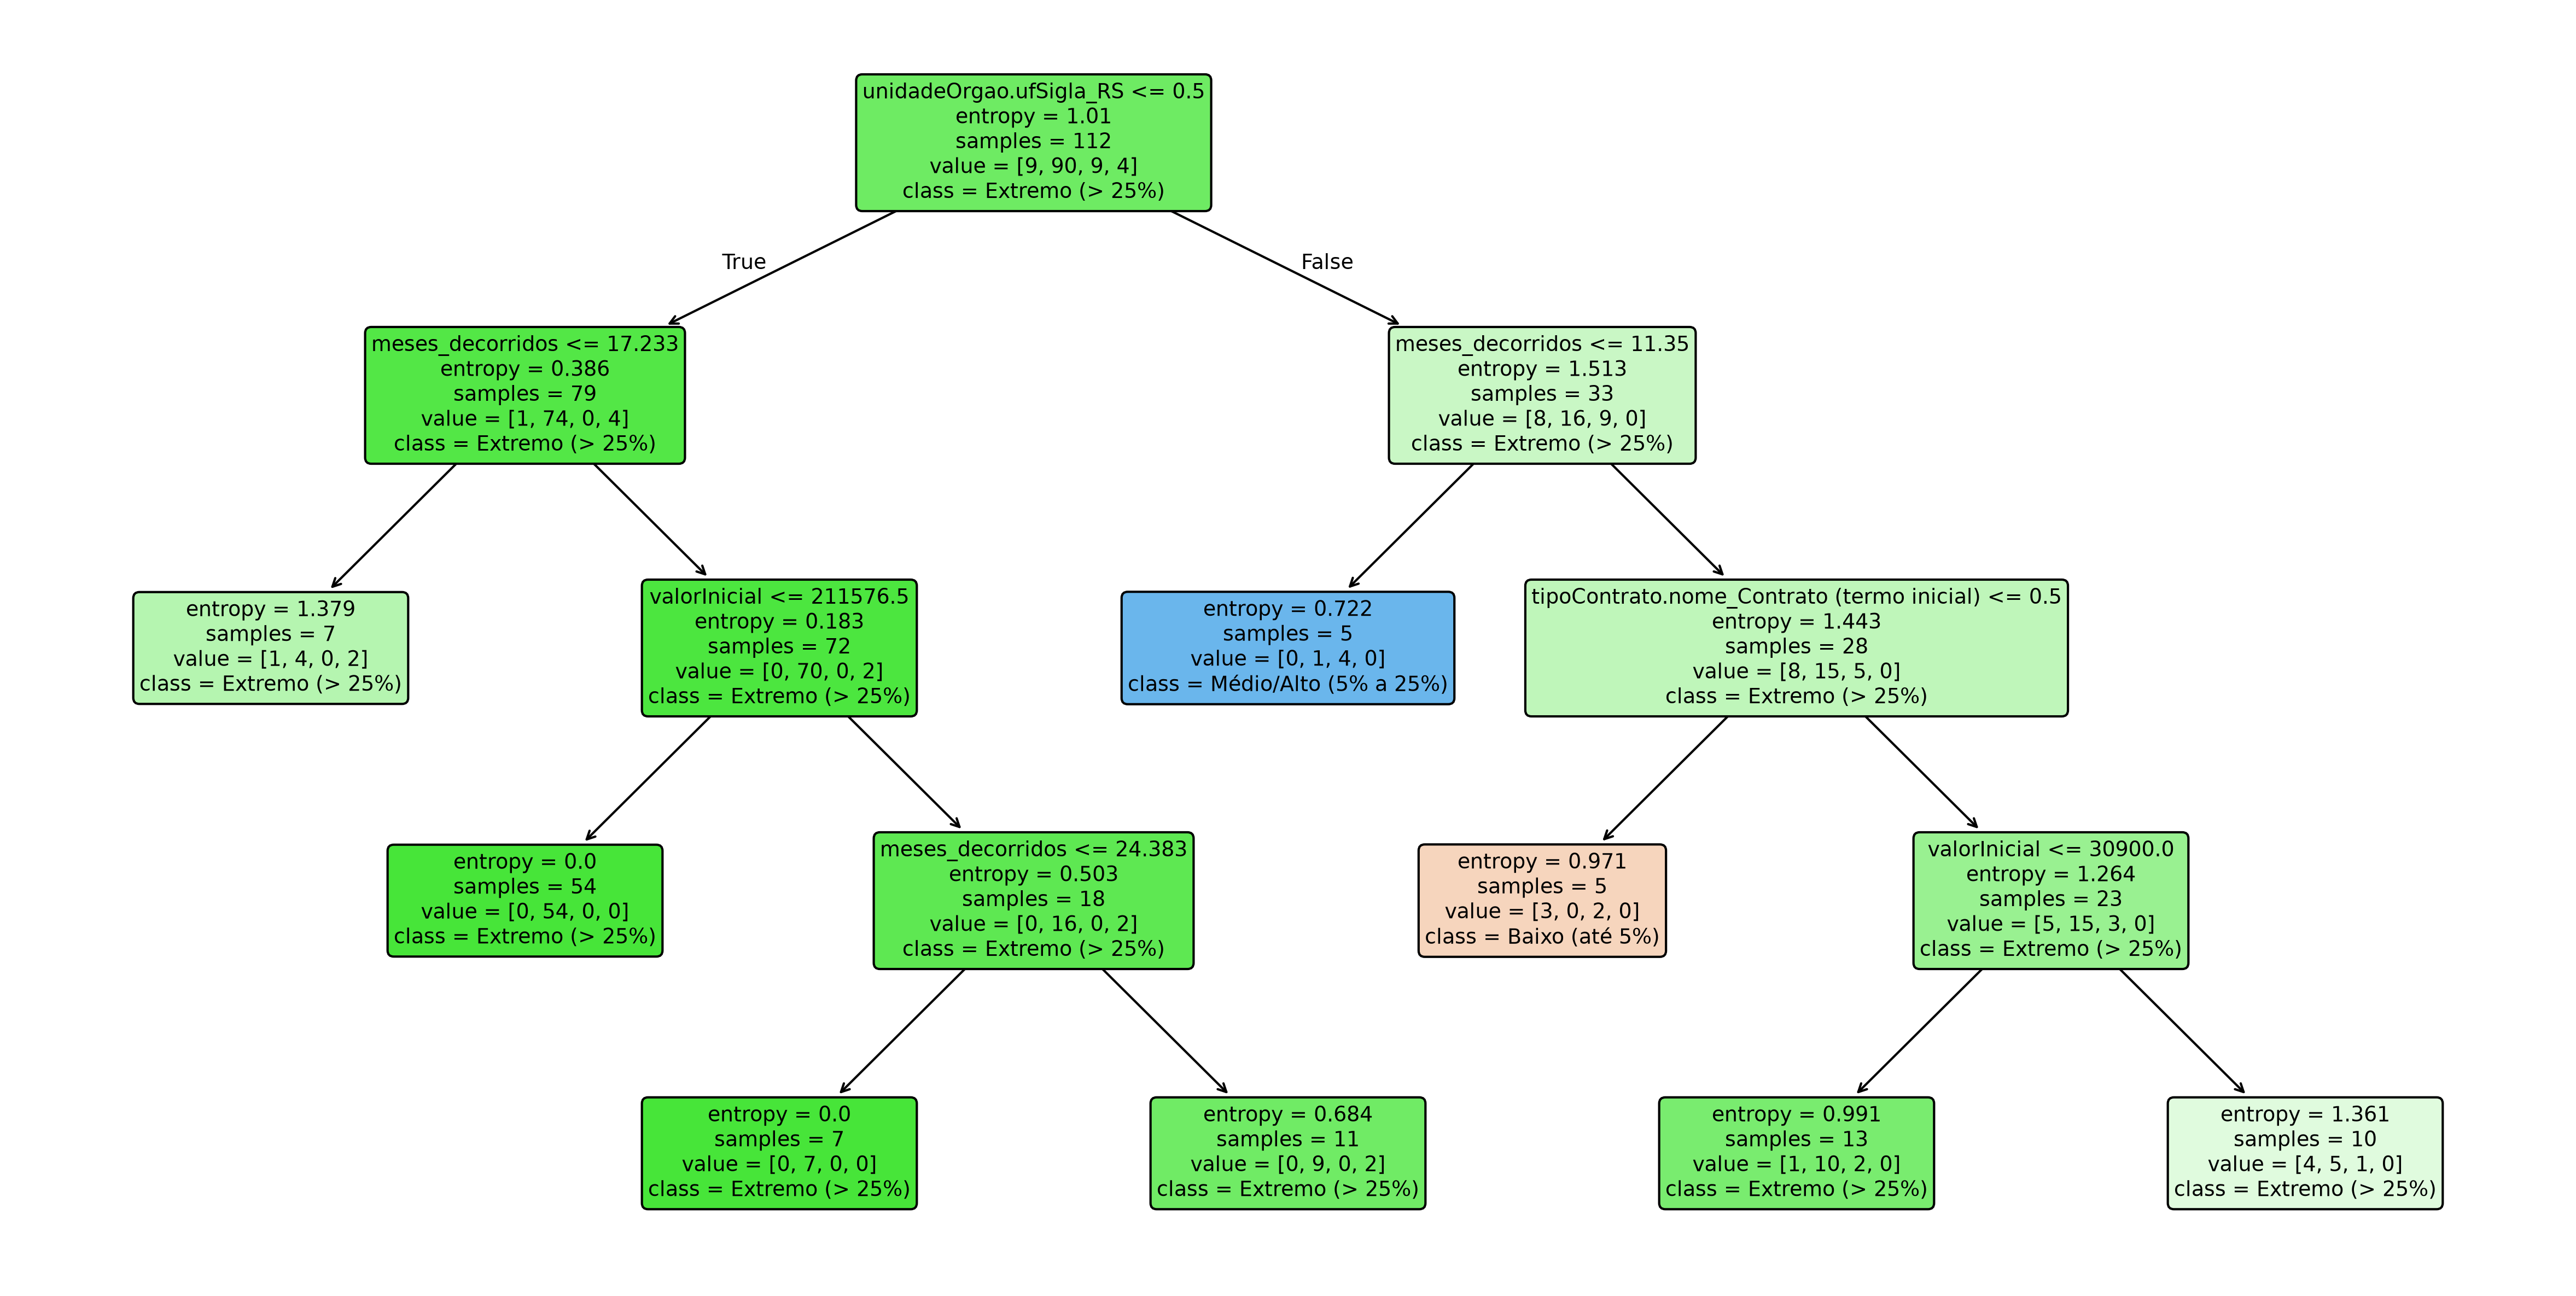

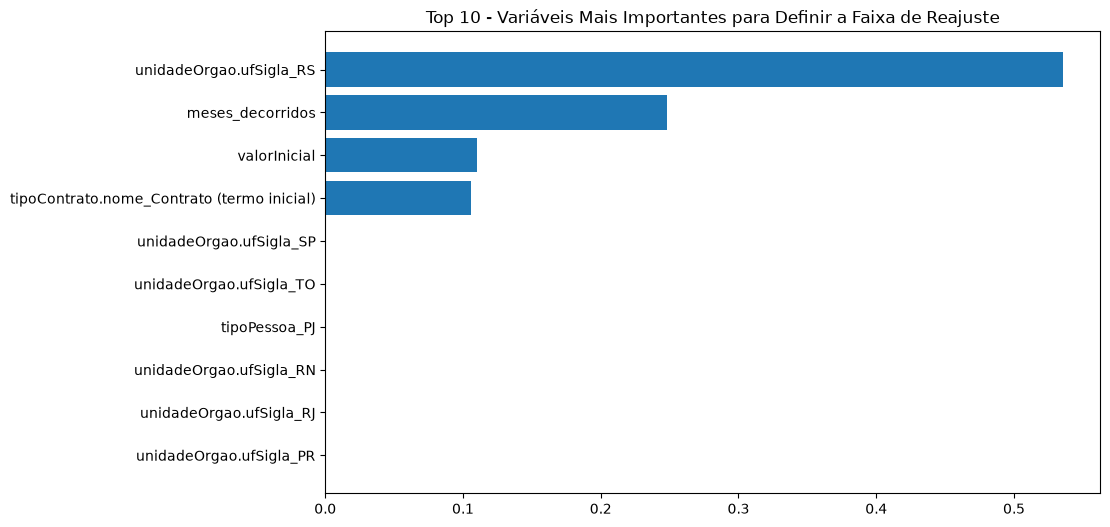

In [ ]:
# 1. Gráfico da Árvore de Decisão
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 10), dpi=300)
tree.plot_tree(clf_stg2,
               feature_names=X_stg2.columns, 
               class_names=clf_stg2.classes_,
               filled=True,
               rounded=True,
               fontsize=9)
fig.savefig('arvore_magnitude.png', bbox_inches='tight')
print("Gráfico da Árvore salvo com sucesso.")

# 2. Gráfico de Feature Importance (Top 10 Variáveis)
feature_importance = clf_stg2.feature_importances_
sorted_idx = np.argsort(feature_importance)

top_n = 10
top_idx = sorted_idx[-top_n:]

fig_imp = plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx)), feature_importance[top_idx], align='center')
plt.yticks(range(len(top_idx)), X_stg2.columns[top_idx])
plt.title('Top 10 - Variáveis Mais Importantes para Definir a Faixa de Reajuste')
fig_imp.savefig('importancia_variaveis.png', bbox_inches='tight')
print("Gráfico de Feature Importance salvo com sucesso.")